# Credit Card Fraud Detection


In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
import os
os.environ["PYTHONHASHSEED"] = "42"

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random

# Fix randomness for reproducibility
np.random.seed(42)
random.seed(42)

# Set style for plots
sns.set(style='whitegrid')

## Load the Dataset

In [ ]:
# Download Credit Card Fraud Detection dataset from Kaggle
import kagglehub
dataset_path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

print("Dataset downloaded to:", dataset_path)

# Load CSV file
csv_file = os.path.join(dataset_path, "creditcard.csv")

df = pd.read_csv(csv_file)

print("Dataset Shape:", df.shape)

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Summary statistics of numerical features
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Display data types of each feature
print("Data Types:")
print(df.dtypes)

# Display dataset information
print("\ndata information:")
df.info()

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 

## Data Cleaning

In [ ]:
# Check for missing values
print("Missing Values Before Cleaning:\n", df.isna().sum())

# Handle missing values
df = df.dropna()

# Check for duplicate rows
print("Duplicates Before Removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Final dataset shape
print("Shape of Dataset After Cleaning:", df.shape)

# Display column names
print("Columns:")
print(df.columns)

Missing Values Before Cleaning:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicates Before Removal: 1081
Shape of Dataset After Cleaning: (283726, 31)
Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


## Class Distribution

Class Distribution (Count):
Class
0    283253
1       473
Name: count, dtype: int64

Class Distribution (%):
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


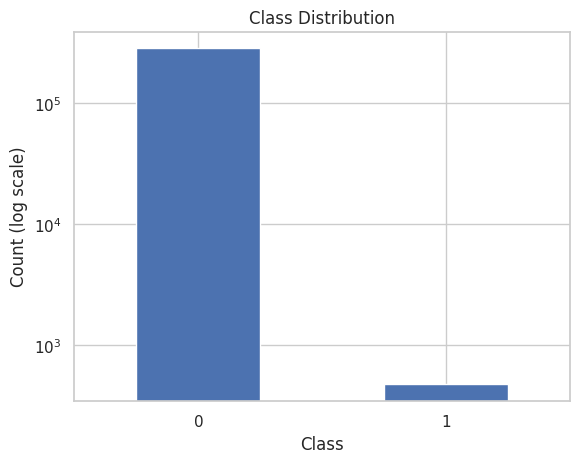

In [ ]:
print("Class Distribution (Count):")
print(df['Class'].value_counts())

print("\nClass Distribution (%):")
print(df['Class'].value_counts(normalize=True) * 100)

df['Class'].value_counts().plot(kind='bar')
plt.yscale('log')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=0)
plt.show()

## Descriptive Statistics

In [ ]:
stats = df.describe().T
stats['median'] = df.median()
statistical_table = stats[['mean', 'median', 'std', 'max', 'min']]
print(statistical_table)

                mean        median           std            max         min
Time    94811.077600  84692.500000  47481.047891  172792.000000    0.000000
V1          0.005917      0.020384      1.948026       2.454930  -56.407510
V2         -0.004135      0.063949      1.646703      22.057729  -72.715728
V3          0.001613      0.179963      1.508682       9.382558  -48.325589
V4         -0.002966     -0.022248      1.414184      16.875344   -5.683171
V5          0.001828     -0.053468      1.377008      34.801666 -113.743307
V6         -0.001139     -0.275168      1.331931      73.301626  -26.160506
V7          0.001801      0.040859      1.227664     120.589494  -43.557242
V8         -0.000854      0.021898      1.179054      20.007208  -73.216718
V9         -0.001596     -0.052596      1.095492      15.594995  -13.434066
V10        -0.001441     -0.093237      1.076407      23.745136  -24.588262
V11         0.000202     -0.032306      1.018720      12.018913   -4.797473
V12        -

## Correlation Analysis

In [ ]:
correlations = df.corr()['Class'].sort_values(ascending=False)
top_10_corr = correlations.head(11)  # includes Class itself
print(top_10_corr)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64


## Correlation Heatmap


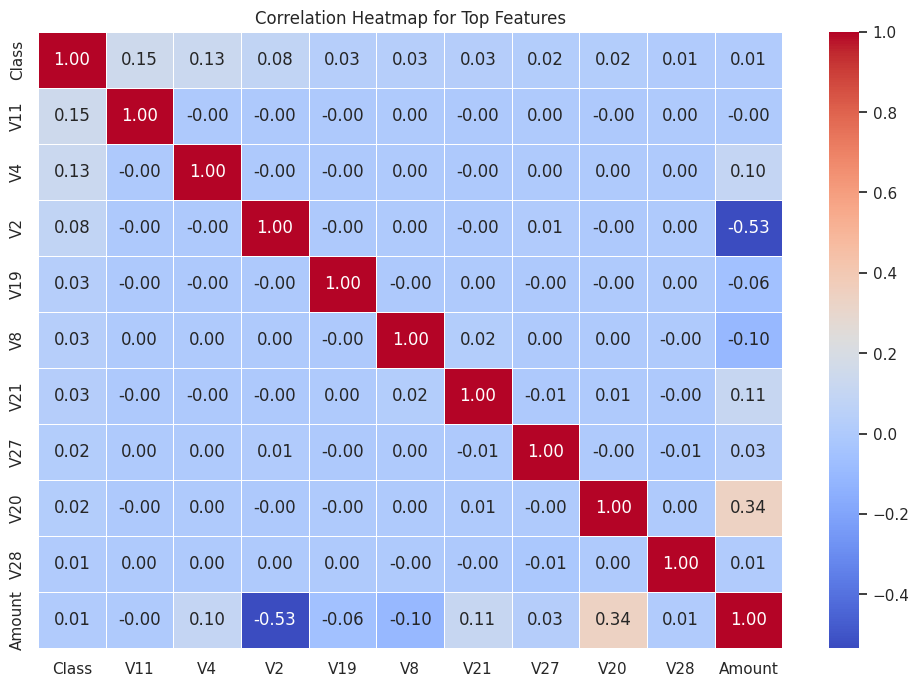

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[top_10_corr.index].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Top Features')
plt.show()

## Feature Ranking Based on Correlation

In [ ]:
feature_corr = abs(df.corr()['Class']).sort_values(ascending=False)

ranked_features = feature_corr.drop('Class')

print(ranked_features.head(20))

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
V1     0.094486
V9     0.094021
V5     0.087812
V2     0.084624
V6     0.043915
V19    0.033631
V8     0.033068
V21    0.026357
V27    0.021892
V20    0.021486
Name: Class, dtype: float64


## Handling Outliers

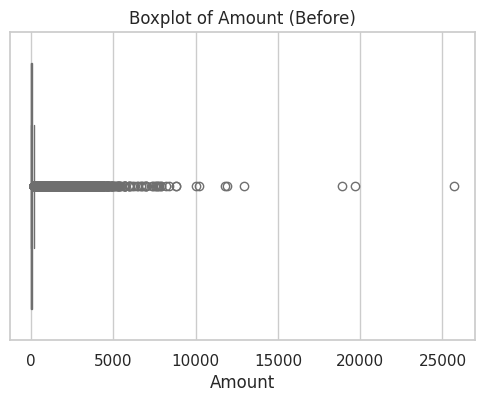

    Time        V1        V2        V3        V4        V5        V6  \
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
20  16.0  0.694885 -1.361819  1.029221  0.834159 -1.191209  1.309109   
51  36.0 -1.004929 -0.985978 -0.038039  3.710061 -6.631951  5.122103   
64  42.0 -0.522666  1.009923  0.276470  1.475289 -0.707013  0.355243   
85  55.0 -4.575093 -4.429184  3.402585  0.903915  3.002224 -0.491078   

          V7        V8        V9  ...       V21       V22       V23       V24  \
2   0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
20 -0.878586  0.445290 -0.446196  ... -0.295583 -0.571955 -0.050881 -0.304215   
51  4.371691 -2.006868 -0.278736  ...  1.393406 -0.381671  0.969719  0.019445   
64  1.559849 -0.399579 -0.479813  ...  0.172401  1.011543  0.069666  0.157820   
85 -2.705393  0.666451  1.922216  ... -0.047365  0.853360 -0.971600 -0.114862   

         V25       V26       V27       V28   Amount  Class  
2  -0.327642 -0.139

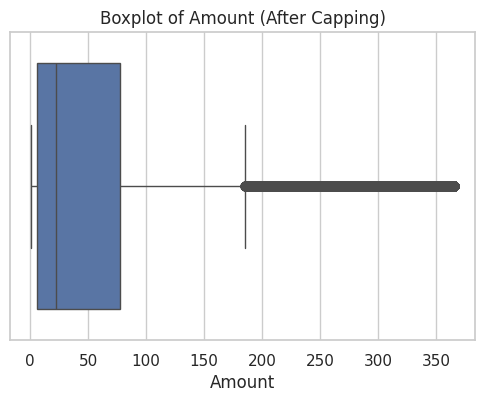

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Amount'], color='skyblue')
plt.title('Boxplot of Amount (Before)')
plt.show()

# Calculate IQR for outlier detection
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(outliers.head())
print("Number of outliers:", outliers.shape[0])

# Cap extreme values (reduce outliers)
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)
df['Amount'] = df['Amount'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Amount (After Capping)')
plt.show()

## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (226980, 30)
Testing set shape: (56746, 30)


## Feature Subset Selection

In [ ]:
top15_features = ranked_features.index[:15].tolist()
top10_features = ranked_features.index[:10].tolist()
top5_features  = ranked_features.index[:5].tolist()

feature_sets = {
    "All Features": X.columns.tolist(),
    "Top 15 Features": top15_features,
    "Top 10 Features": top10_features,
    "Top 5 Features": top5_features
    }

## Feature Selection Evaluation Using Random Forest

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results_fs = []

for name, features in feature_sets.items():

    X_subset = X[features]

    pipe = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            n_estimators=50,
            max_depth=None,
            random_state=42,
            n_jobs=1
        ))
    ])

    scores = cross_validate(
        pipe,
        X_subset,
        y,
        cv=cv,
        scoring={
            'f1': 'f1',
            'recall': 'recall',
            'precision': 'precision'
        },
        n_jobs=1
    )

    results_fs.append([
        name,
        len(features),
        scores['test_precision'].mean(),
        scores['test_recall'].mean(),
        scores['test_f1'].mean()
    ])

fs_results = pd.DataFrame(
    results_fs,
    columns=[
        'Feature Set',
        'No. Features',
        'Precision',
        'Recall',
        'F1'
    ]
)

fs_results.sort_values('F1', ascending=False)

,Feature Set,No. Features,Precision,Recall,F1
0,All Features,30,0.877427,0.820151,0.847321
1,Top 15 Features,15,0.851363,0.811766,0.830968
2,Top 10 Features,10,0.794328,0.815972,0.804869
3,Top 5 Features,5,0.494317,0.807533,0.612772


## Data Transformation – Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[['Amount', 'Time']])

X_train = X_train.copy()
X_test = X_test.copy()

X_train.loc[:, ['Amount', 'Time']] = scaler.transform(X_train[['Amount', 'Time']])
X_test.loc[:, ['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

print("After Normalization:")
print(X_train[['Amount', 'Time']].head())
print("\nStatistics after normalization:")
print(X_train[['Amount', 'Time']].describe())

After Normalization:
          Amount      Time
226238 -0.345706  1.045499
134253 -0.604878 -0.298690
186465 -0.522390  0.678397
149493 -0.498038 -0.074929
18461  -0.428608 -1.376728

Statistics after normalization:
             Amount          Time
count  2.269800e+05  2.269800e+05
mean  -6.151275e-18  1.558949e-17
std    1.000002e+00  1.000002e+00
min   -6.677794e-01 -1.998400e+00
25%   -6.183492e-01 -8.561822e-01
50%   -4.485041e-01 -2.123526e-01
75%    1.294252e-01  9.363191e-01
max    3.108580e+00  1.640237e+00


## Data Reduction – Principal Component Analysis (PCA)

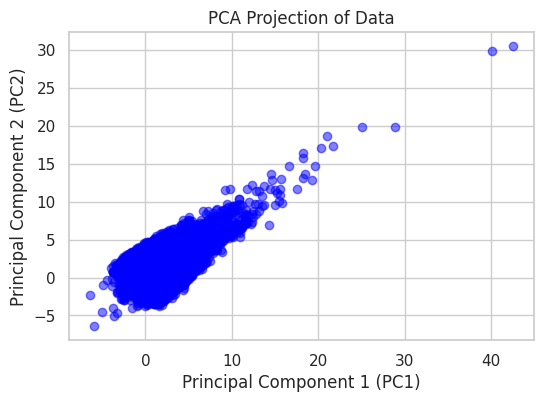

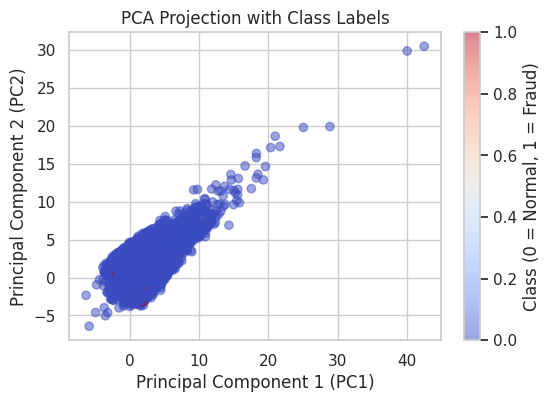

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X_train)

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

y_train_array = y_train.values

# Visualization 1: PCA Projection (no labels)
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5, color='blue')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection of Data")
plt.show()

# Visualization 2: PCA with Class Labels
plt.figure(figsize=(6, 4))
plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=y_train_array,
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection with Class Labels")
plt.colorbar(label='Class (0 = Normal, 1 = Fraud)')
plt.show()

## SMOTE (Handle Imbalanced Data)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE:
 Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
 Class
0    226602
1    226602
Name: count, dtype: int64


## Models Initialization & Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=1)
}

results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print("=" * 50)
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-Score:", f1)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.9737778874281888
Precision: 0.05323925593329057
Recall: 0.8736842105263158
F1-Score: 0.1003627569528416

Confusion Matrix:
[[55175  1476]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Decision Tree
Accuracy: 0.9976914672399817
Precision: 0.39285714285714285
Recall: 0.6947368421052632
F1-Score: 0.5019011406844106

Confusion Matrix:
[[56549   102]
 [   29    66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.39      0.69      0.50        95

    accuracy                           1.00     56746
   macro avg       0.70      0.85      0.

<Figure size 600x500 with 0 Axes>

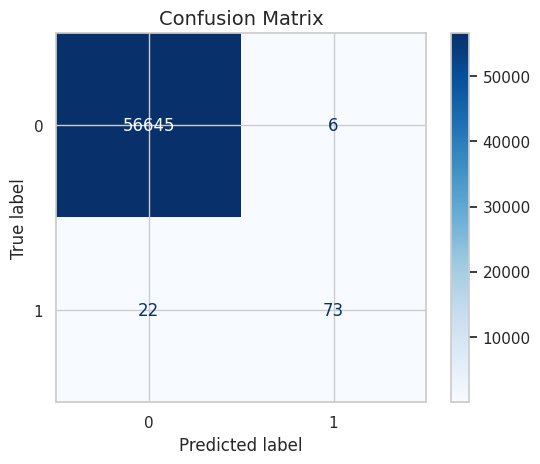

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix", fontsize=14)
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


Final Results Table:
                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.999507   0.924051  0.768421  0.839080
1        Decision Tree  0.997691   0.392857  0.694737  0.501901
0  Logistic Regression  0.973778   0.053239  0.873684  0.100363


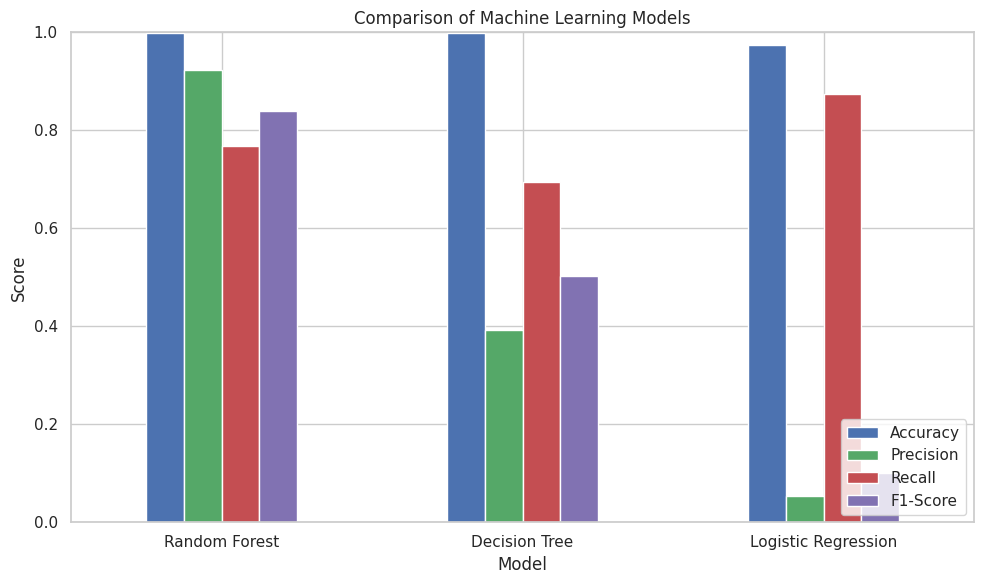

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\nFinal Results Table:")
print(results_df)

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6),
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2']
)
plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Cross Validation


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():

    pipeline_cv = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline_cv,
        X_train,
        y_train,
        cv=cv,
        scoring=['f1', 'recall'],
        n_jobs=1
    )

    cv_results[name] = {
        "F1 Score": np.mean(scores['test_f1']),
        "Recall": np.mean(scores['test_recall'])
    }

print("Cross Validation Results:\n")
for name, res in cv_results.items():
    print(f"{name}: F1 = {res['F1 Score']:.4f}, Recall = {res['Recall']:.4f}")

Cross Validation Results:

Logistic Regression: F1 = 0.1032, Recall = 0.9153
Decision Tree: F1 = 0.5360, Recall = 0.7751
Random Forest: F1 = 0.8434, Recall = 0.8042


## Grid Search (Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))
])

param_grid = {
    "model__n_estimators": [50],
    "model__max_depth": [None, 10]
}

cv_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_gs,
    scoring='f1',
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Final Evaluation (Best Model):\n")
print(classification_report(y_test, y_pred_best))

Best Parameters: {'model__max_depth': None, 'model__n_estimators': 50}
Final Evaluation (Best Model):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



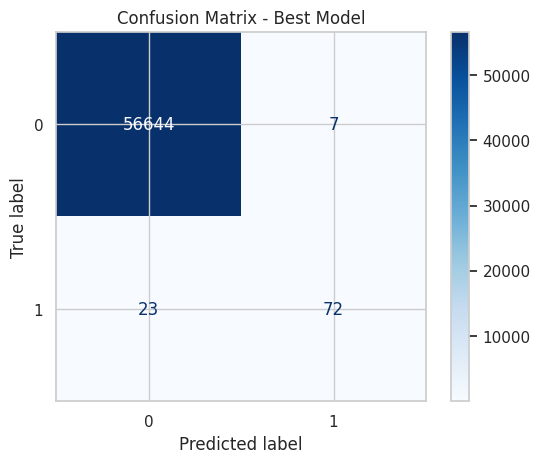

In [ ]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.show()

## ROC Curve (Model Evaluation)

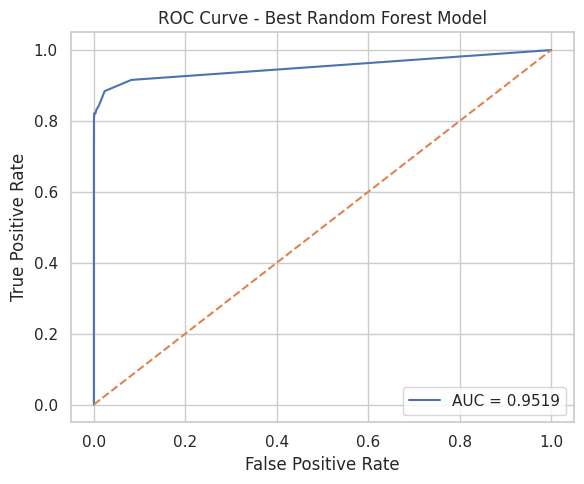

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')  # baseline (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Random Forest Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

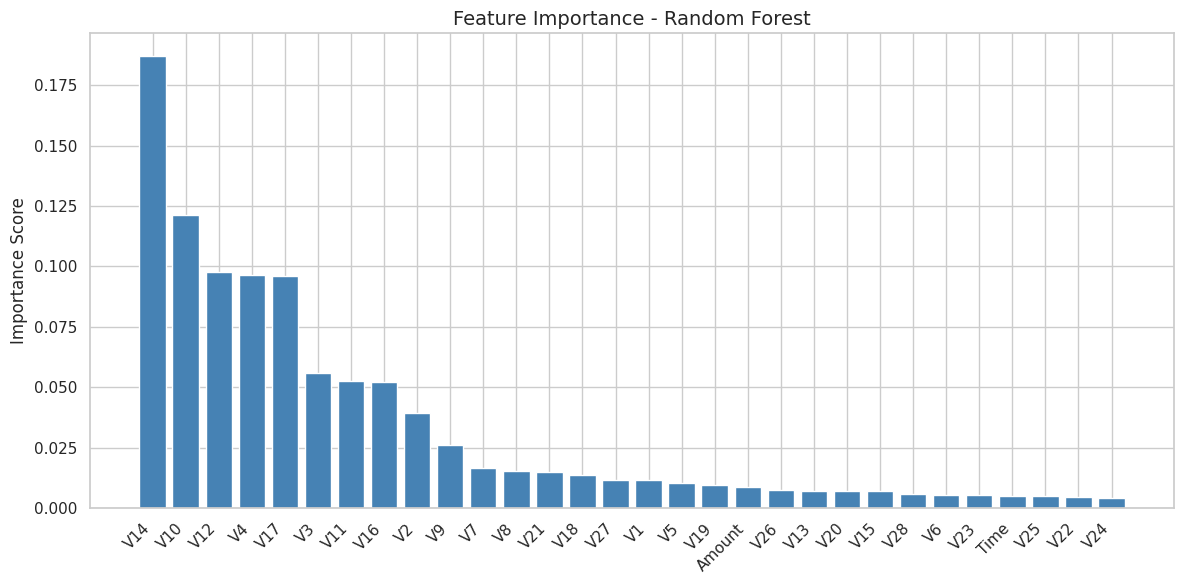

In [ ]:
rf_model = models['Random Forest']

importances = rf_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importance - Random Forest", fontsize=14)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()